In [205]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from math import exp,log
from dotenv import load_dotenv

load_dotenv()
data_path = str(os.getenv("Data_path"))

df = pd.read_csv(data_path)

print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   patient_id           1000 non-null   int64  
 1   age                  1000 non-null   int64  
 2   gender               1000 non-null   str    
 3   glucose_mg_dl        1000 non-null   int64  
 4   cholesterol_mg_dl    1000 non-null   int64  
 5   systolic_bp          1000 non-null   int64  
 6   diastolic_bp         1000 non-null   int64  
 7   bmi                  1000 non-null   float64
 8   heart_rate           1000 non-null   int64  
 9   smoking              1000 non-null   str    
 10  alcohol_consumption  1000 non-null   str    
 11  physical_activity    1000 non-null   str    
 12  family_history       1000 non-null   str    
 13  disease              1000 non-null   str    
dtypes: float64(1), int64(7), str(6)
memory usage: 109.5 KB
None


In [206]:
df['gender'] = df['gender'].map({'Male':1,'Female':0})
df['smoking'] = df['smoking'].map({'Yes':1,'No':0})
df['alcohol_consumption'] = df['alcohol_consumption'].map({'Yes':1,'No':0})
df['disease'] = df['disease'].map({'Yes':1,'No':0})

print(df.head(5))

   patient_id  age  gender  glucose_mg_dl  cholesterol_mg_dl  systolic_bp  \
0           1   32       1            101                235          152   
1           2   31       1            124                191          134   
2           3   45       1             57                141          114   
3           4   75       0             69                268          120   
4           5   53       1            107                163          131   

   diastolic_bp   bmi  heart_rate  smoking  alcohol_consumption  \
0            79  28.5          73        0                    1   
1            77  33.9          71        0                    1   
2            71  27.2          79        1                    1   
3            82  21.5          61        1                    1   
4            75  23.3          73        1                    0   

  physical_activity family_history  disease  
0               Low            Yes        1  
1               Low            Yes        

/tmp/ipykernel_2279/1043687606.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df,x='disease',y=feature,ax=axes,palette=['seagreen','indianred'])
/tmp/ipykernel_2279/1043687606.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes.set_xticklabels(['healthy','Not healthy'])
/tmp/ipykernel_2279/1043687606.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df,x='disease',y=feature,ax=axes,palette=['seagreen','indianred'])
/tmp/ipykernel_2279/1043687606.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax

Text(0.5, 1.0, 'Correlation Heatmap')

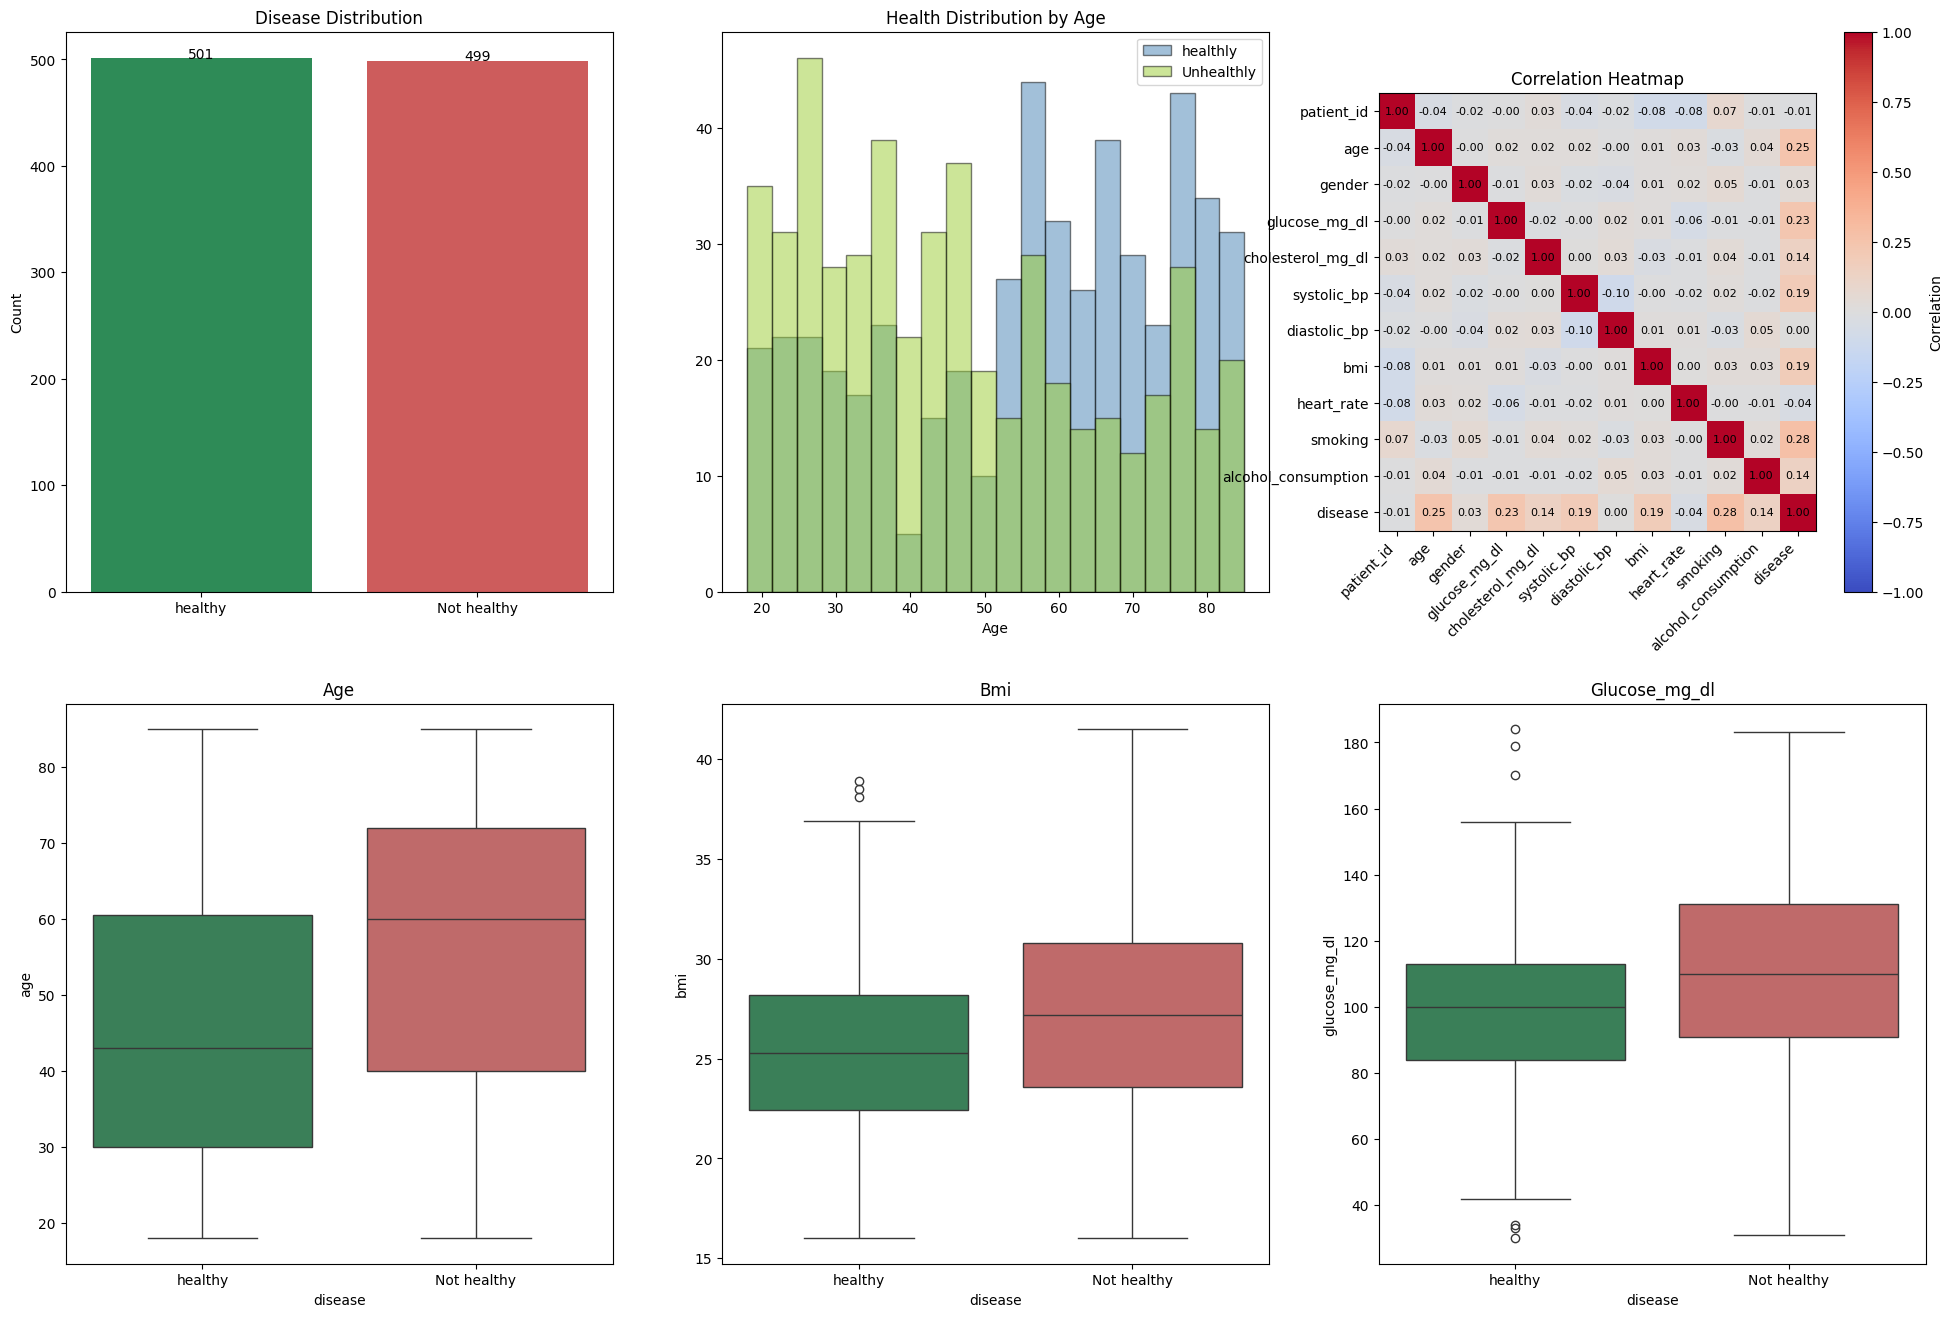

In [207]:
fig,ax = plt.subplots(ncols=3,nrows=2,figsize=(24,16))
ishealthy = (df['disease']==1).sum()
nothealthy = (df['disease']==0).sum()

#bar
health = ax[0,0]
bars= health.bar(["healthy","Not healthy"],[ishealthy,nothealthy],color =['seagreen','indianred'])

for b in bars:
    height =  b.get_height()
    health.annotate(f"{height}",xy=(b.get_x()+b.get_width()/2,height),ha='center')

health.set_title("Disease Distribution")
health.set_ylabel("Count")

#histogram

ax[0,1].hist(df.loc[df['disease']==1,'age'],bins=20,color='steelblue',ec='black',label='healthly',alpha=0.5)
ax[0,1].hist(df.loc[df['disease']==0,'age'],bins=20,color='yellowgreen',ec='black',label='Unhealthly',alpha=0.5)
ax[0,1].legend()
ax[0,1].set_title("Health Distribution by Age")
ax[0,1].set_xlabel("Age")

#Box
features = ['age','bmi','glucose_mg_dl']

for axes,feature in zip(ax[1],features):
    sns.boxplot(data=df,x='disease',y=feature,ax=axes,palette=['seagreen','indianred'])
    axes.set_xticklabels(['healthy','Not healthy'])
    axes.set_title(f"{feature.capitalize()}")

#correlation matrix
corr = df.corr(numeric_only=True)
#print(corr)
heat = ax[0,2]
im = heat.imshow(corr,cmap='coolwarm',vmin=-1,vmax=1)

heat.set_xticks(range(len(corr.columns)))
heat.set_yticks(range(len(corr.columns)))
heat.set_xticklabels(corr.columns,rotation=45,ha='right')
heat.set_yticklabels(corr.columns)

for i in range(len(corr)):
    for j in range(len(corr)):
        heat.text(j,i,f"{corr.iloc[i,j]:.2f}",ha='center',va='center',color='black',fontsize=8)

fig.colorbar(im,ax=heat,label='Correlation')
heat.set_title("Correlation Heatmap")



In [208]:
df = pd.get_dummies(df,columns=['physical_activity'],drop_first=True,dtype=int)

print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   patient_id                1000 non-null   int64  
 1   age                       1000 non-null   int64  
 2   gender                    1000 non-null   int64  
 3   glucose_mg_dl             1000 non-null   int64  
 4   cholesterol_mg_dl         1000 non-null   int64  
 5   systolic_bp               1000 non-null   int64  
 6   diastolic_bp              1000 non-null   int64  
 7   bmi                       1000 non-null   float64
 8   heart_rate                1000 non-null   int64  
 9   smoking                   1000 non-null   int64  
 10  alcohol_consumption       1000 non-null   int64  
 11  family_history            1000 non-null   str    
 12  disease                   1000 non-null   int64  
 13  physical_activity_Low     1000 non-null   int64  
 14  physical_activity_Me

In [209]:
df['family_history'] = df['family_history'].map({'Yes':1,'No':0})

print(df.head(2).to_string())

   patient_id  age  gender  glucose_mg_dl  cholesterol_mg_dl  systolic_bp  diastolic_bp   bmi  heart_rate  smoking  alcohol_consumption  family_history  disease  physical_activity_Low  physical_activity_Medium
0           1   32       1            101                235          152            79  28.5          73        0                    1               1        1                      1                         0
1           2   31       1            124                191          134            77  33.9          71        0                    1               1        1                      1                         0


In [210]:
print(df.shape)
#print(df.isnull().sum)
print(df.info())

(1000, 15)
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   patient_id                1000 non-null   int64  
 1   age                       1000 non-null   int64  
 2   gender                    1000 non-null   int64  
 3   glucose_mg_dl             1000 non-null   int64  
 4   cholesterol_mg_dl         1000 non-null   int64  
 5   systolic_bp               1000 non-null   int64  
 6   diastolic_bp              1000 non-null   int64  
 7   bmi                       1000 non-null   float64
 8   heart_rate                1000 non-null   int64  
 9   smoking                   1000 non-null   int64  
 10  alcohol_consumption       1000 non-null   int64  
 11  family_history            1000 non-null   int64  
 12  disease                   1000 non-null   int64  
 13  physical_activity_Low     1000 non-null   int64  
 14  physical_

In [ ]:
y= df['disease'].values

df.drop(columns=['disease','patient_id'],inplace=True)

x= df.values


In [212]:
np.random.seed(69)

idx = np.random.permutation(len(x))
split = int(0.8*len(x))

x_train,x_test = x[idx[:split]],x[idx[split:]]
y_train,y_test = y[idx[:split]],y[idx[split:]]

print(x_train.shape)
print(y_train.shape)
print(df.info())

(800, 13)
(800,)
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1000 non-null   int64  
 1   gender                    1000 non-null   int64  
 2   glucose_mg_dl             1000 non-null   int64  
 3   cholesterol_mg_dl         1000 non-null   int64  
 4   systolic_bp               1000 non-null   int64  
 5   diastolic_bp              1000 non-null   int64  
 6   bmi                       1000 non-null   float64
 7   heart_rate                1000 non-null   int64  
 8   smoking                   1000 non-null   int64  
 9   alcohol_consumption       1000 non-null   int64  
 10  family_history            1000 non-null   int64  
 11  physical_activity_Low     1000 non-null   int64  
 12  physical_activity_Medium  1000 non-null   int64  
dtypes: float64(1), int64(12)
memory usage: 101.7 KB
None


In [213]:
con_col= [0,2,3,4,5,6,7]

mu = x_train[:,con_col].mean(axis=0)
std = x_train[:,con_col].std(axis=0)

x_train_n = x_train.copy().astype(float)
x_test_n = x_test.copy().astype(float)

x_train_n[:,con_col] = (x_train[:,con_col]-mu)/std
x_test_n[:,con_col] = (x_test[:,con_col]-mu)/std

print(x_train_n)

[[ 0.1917479   0.         -1.38161082 ...  0.          1.
   0.        ]
 [ 1.60230718  1.          0.2228728  ...  0.          0.
   0.        ]
 [-0.81579444  0.         -2.18385264 ...  0.          0.
   1.        ]
 ...
 [ 1.35042159  1.         -0.29858437 ...  1.          0.
   1.        ]
 [ 0.24212502  1.          2.30870152 ...  0.          0.
   0.        ]
 [-0.31202327  0.         -2.82564609 ...  1.          1.
   0.        ]]


0.0 0.0 0.0
Epoch    0  J(θ) = 0.673557
Epoch   50  J(θ) = 0.475610
Epoch  100  J(θ) = 0.430348
Epoch  150  J(θ) = 0.404388
Epoch  200  J(θ) = 0.387356
Epoch  250  J(θ) = 0.375398
Epoch  300  J(θ) = 0.366636
Epoch  350  J(θ) = 0.360020
Epoch  400  J(θ) = 0.354908
Epoch  450  J(θ) = 0.350886


Text(0.5, 1.0, 'Log-Loss convergence')

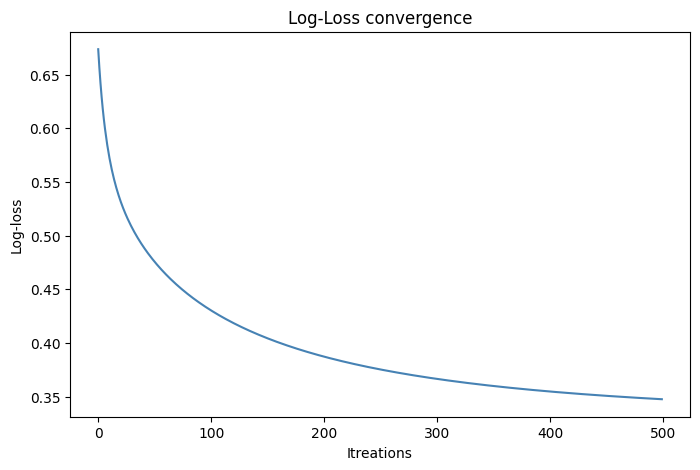

In [218]:
def sigmoid(z):
    return 1/(1+np.exp(-z))

def log_likelyhood(theta,X_m_train,y_train):
    m = len(y_train)
    h = sigmoid(X_m_train @ theta)
    h = np.clip(h, 1e-9, 1 - 1e-9)
    return -(1/m)*np.sum(y_train*np.log(h)+(1-y_train)*np.log(1-h))

def Gradient(x_train_n,y_train,rate=0.001,epochs=500):
    m = len(x_train_n)
    n = len(x_train_n[1])

    X_m_train = np.column_stack([np.ones(m),x_train_n])
    theta = np.zeros(X_m_train.shape[1])
    Mle =[]
    z = X_m_train @ theta

    print(z.min(),z.max(),z.mean())

    for epoch in range(epochs):
        h = sigmoid(X_m_train @ theta) 
        error = h - y_train
        grad = (1/m)* X_m_train.T @ error
        theta -= (rate)*grad
        
        Mle.append(log_likelyhood(theta,X_m_train,y_train))

        if epoch % 50 == 0:
            print(f"Epoch {epoch:>4}  J(θ) = {Mle[-1]:.6f}")
        
        if len(Mle) > 1 and abs(Mle[-2] - Mle[-1]) < 1e-6:
            print(f"Converged at epoch {epoch}")
            break

    return theta,Mle


theta,history = Gradient(x_train_n,y_train,rate= 0.3,epochs=500)

fig2 , ax2 = plt.subplots(figsize=(8,5))
sns.lineplot(x=range(len(history)),y=history,ax=ax2,color='steelblue')
ax2.set_xlabel("Itreations")
ax2.set_ylabel("Log-loss")
ax2.set_title('Log-Loss convergence')

In [ ]:
m_test = len(x_test_n)

X_m_test = np.column_stack([np.ones(m_test),x_test_n])

probabilites = sigmoid(X_m_test @ theta)

prediction = (probabilites>=0.5).astype(int)

print(prediction)

[0 1 1 0 1 1 0 1 0 1 0 1 1 0 0 0 0 0 0 1 1 0 1 1 0 0 0 0 1 0 1 1 0 1 0 0 1
 1 1 0 1 1 1 1 0 1 1 0 0 0 0 1 1 0 0 1 1 1 1 1 1 0 0 1 1 1 0 1 0 1 1 0 0 0
 0 0 0 0 1 0 1 0 0 0 1 1 1 1 1 0 0 0 0 0 1 1 1 1 1 0 1 1 1 1 1 1 1 0 0 0 1
 0 0 1 1 0 1 0 1 0 0 1 1 1 1 1 1 0 1 0 1 0 0 0 0 1 0 1 0 0 0 1 1 0 0 0 0 1
 1 1 1 1 1 1 0 0 1 0 0 0 0 1 1 0 0 0 1 1 0 0 1 0 1 1 0 0 1 0 0 0 0 0 1 1 0
 0 1 1 1 0 0 1 0 0 1 1 1 0 1 1]


accuracy : 0.84
TP : 86 TN: 82 FP:16 FN: 16


Text(0.5, 1.0, 'Confusion Matric')

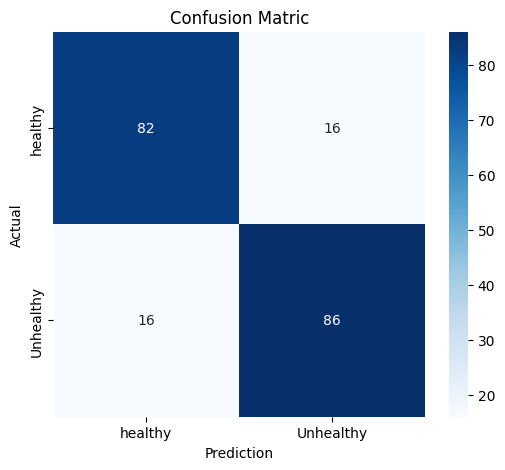

In [221]:
accuracy = np.mean(prediction == y_test)

print(f"accuracy : {accuracy:.2f}")

TP = np.sum((prediction==1)&(y_test==1))
TN = np.sum((prediction==0)&(y_test==0))
FP = np.sum((prediction==1)&(y_test==0))
FN = np.sum((prediction==0)&(y_test==1))

print(f"TP : {TP} TN: {TN} FP:{FP} FN: {FN}")

cm = np.array([[TN,FP],[FN,TP]])

fig3,ax3 = plt.subplots(figsize=(6,5))

sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',
            xticklabels=['healthy','Unhealthy'],
            yticklabels=['healthy','Unhealthy'],
            ax=ax3)
ax3.set_xlabel("Prediction")
ax3.set_ylabel("Actual")
ax3.set_title("Confusion Matric")


In [ ]:
Recall = TP/(TP+FN)
precision = TP/(TP+FP)

print(f"Recall : {Recall:.4f} Precision : {precision:.4f}")

Recall : 0.8431 Precision : 0.8431
